In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import math 
import sklearn 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
#make a train-test split 

In [16]:
filename1 = 'Combined_Data.csv'
filename2 = 'Combined_Data_Two_weeks.csv'
new_data = pd.read_csv(filename1)
old_data = pd.read_csv(filename2) 
new_data['View Count'] = new_data['View Count'].str.replace(',', '').astype(int)
old_data['View Count'] = old_data['View Count'].str.replace(',', '').astype(int)
data = old_data
data['Post 2 Weeks View Count'] = new_data['View Count']
data['Video Posted'] = pd.to_datetime(data['Video Posted'])
data['Video Posted'] = data['Video Posted'].dt.tz_localize(None)
# 2. Define the reference date (February 11, 2025)
reference_date = pd.Timestamp('2025-02-11')
# 3. Calculate time difference in days, rounding to the nearest whole day
data['time_since_posting'] = (
    (reference_date - data['Video Posted']).dt.total_seconds() / 86400
).round().astype(int)
data

,Channel Name,Subscriber Count,Total Videos,Total Views,View Count,Like Count,Comment Count,Video Posted,Video Link,Post 2 Weeks View Count,time_since_posting
0,The Infographics Show,14800000,5354,6251451295,14149,936,225,2025-02-11 00:11:00,https://www.youtube.com/watch?v=w2SYMSemBI0&ab...,64213,0
1,The Infographics Show,14800000,5354,6251451295,267615,9021,1621,2025-02-09 15:11:00,https://www.youtube.com/watch?v=beWI6TOjXG4&ab...,562089,1
2,The Infographics Show,14800000,5354,6251451295,25730,338,26,2025-02-09 03:11:00,https://www.youtube.com/watch?v=XVS3vFs7sBU&ab...,43791,2
3,The Infographics Show,14800000,5354,6251451295,67402,1721,193,2025-02-08 15:11:00,https://www.youtube.com/watch?v=p8YmQPzknNg&ab...,82292,2
4,The Infographics Show,14800000,5354,6251451295,90882,3079,442,2025-02-08 00:37:00,https://www.youtube.com/watch?v=F9EWqjuWlwQ&ab...,185774,3
...,...,...,...,...,...,...,...,...,...,...,...
265,Physics Explained,238000,26,11500176,213650,8049,465,2025-01-20 21:00:06,https://www.youtube.com/watch?v=vjDvBP5IU-4,260821,21
266,Physics Explained,238000,26,11500176,87393,3349,259,2025-01-27 20:00:06,https://www.youtube.com/watch?v=zvyxArI67vw,97308,14
267,Physics Explained,238000,26,11500176,19475,1362,105,2025-01-12 17:59:29,https://www.youtube.com/watch?v=hMkUdTQ2amw,20035,29
268,Periodic Videos,1620000,729,290600849,46377,3688,262,2025-01-21 13:38:06,https://www.youtube.com/watch?v=xNbDe0K-p8w,47996,20


In [24]:
np.mean(data['View Count'])*.221

76500.26727777778

# Including Views

Coefficients: [[ 6.44416237e-03 -3.52389684e+00  1.07032573e-06  1.03237607e+00
   7.56381191e+00 -1.16969617e+01 -3.30157986e+03]]
Intercept: [14949.537047]
R^2 (Train): 0.9131316378492655, R^2 (Test): 0.9840105179627499
1.6156737309587306e-59
                               OLS Regression Results                              
Dep. Variable:     Post 2 Weeks View Count   R-squared:                       0.932
Model:                                 OLS   Adj. R-squared:                  0.931
Method:                      Least Squares   F-statistic:                     515.6
Date:                     Wed, 05 Mar 2025   Prob (F-statistic):          3.16e-149
Time:                             23:20:20   Log-Likelihood:                -3777.5
No. Observations:                      270   AIC:                             7571.
Df Residuals:                          262   BIC:                             7600.
Df Model:                                7                                         

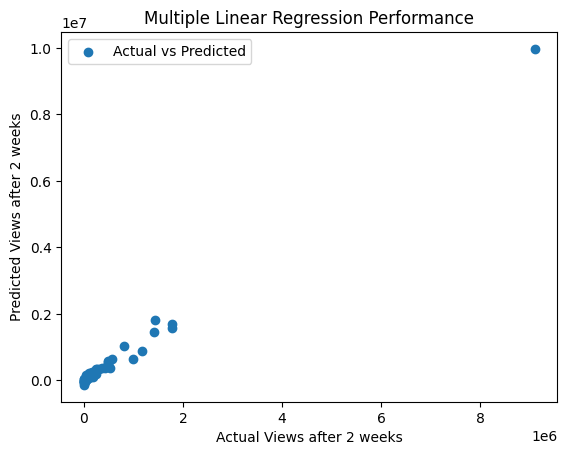

In [7]:
# Select all numeric columns except the target variable
drop_columns = ['Post 2 Weeks View Count']  # Target variable
X = data.select_dtypes(include=[np.number]).drop(columns=drop_columns)
y = data[['Post 2 Weeks View Count']]

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Model evaluation
coefficients = model.coef_
intercept = model.intercept_
r_squared_train = model.score(X_train, y_train)
r_squared_test = model.score(X_test, y_test)
y_pred = model.predict(X_test)

print(f"Coefficients: {coefficients}")
print(f"Intercept: {intercept}")
print(f"R^2 (Train): {r_squared_train}, R^2 (Test): {r_squared_test}")

# OLS Regression Analysis
X_with_const = sm.add_constant(X)  # Adding a constant term for statsmodels regression
ols_model = sm.OLS(y, X_with_const).fit()
like_count_p_value = ols_model.pvalues.get('View Count', None)
print(like_count_p_value)
print(ols_model.summary())

# Plot results
plt.scatter(y_test, y_pred, label="Actual vs Predicted")
plt.xlabel('Actual Views after 2 weeks')
plt.ylabel('Predicted Views after 2 weeks')
plt.title('Multiple Linear Regression Performance')
plt.legend()
plt.show()


In [26]:
print(X.describe())

       Subscriber Count  Total Videos   Total Views     Like Count  \
count      2.700000e+02    270.000000  2.700000e+02     270.000000   
mean       9.721198e+06   3426.918519  2.690349e+09   10346.651852   
std        6.624125e+06   2933.186497  2.198169e+09   24906.009582   
min        4.500000e+03     26.000000  3.811350e+05       4.000000   
25%        3.610000e+06   1311.000000  6.571567e+08     485.250000   
50%        8.790000e+06   2784.000000  2.083521e+09    2849.500000   
75%        1.330000e+07   4690.250000  5.034992e+09    7834.750000   
max        2.420000e+07  10518.000000  6.280203e+09  189975.000000   

       Comment Count  time_since_posting  
count     270.000000          270.000000  
mean      727.348148           20.951852  
std      1909.462253           14.982316  
min         0.000000            0.000000  
25%        30.000000            9.000000  
50%       157.500000           19.000000  
75%       476.000000           27.000000  
max     18363.000000     

## Single Variable OLS

Slope: [1.22155446], Intercept: [3416.99075071]
R^2 (Train): 0.902649713338734, R^2 (Test): 0.9826053725401253


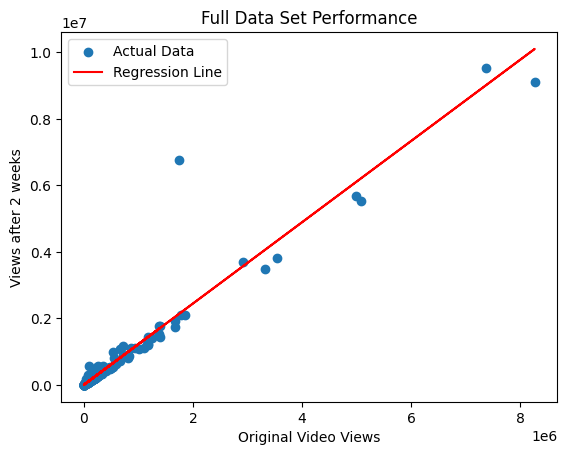

In [19]:
# Prepare data
a = np.array(data['View Count']).reshape(-1,1)
b = np.array(data['time_since_posting']).reshape(-1,1)
c = np.array(data['Post 2 Weeks View Count'])

x = data[['View Count']]
y = data[['Post 2 Weeks View Count']]

# Split data into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=69)

# Train model
model = LinearRegression()
model.fit(x_train, y_train)

# Model evaluation
slope = model.coef_[0]
intercept = model.intercept_
r_squared_train = model.score(x_train, y_train)
r_squared_test = model.score(x_test, y_test)
y_pred = model.predict(x_test)

print(f"Slope: {slope}, Intercept: {intercept}")
print(f"R^2 (Train): {r_squared_train}, R^2 (Test): {r_squared_test}")

# Plot results
plt.scatter(x,y, label="Actual Data")
plt.plot(x_test, y_pred, color='red', label="Regression Line")
plt.xlabel('Original Video Views')
plt.ylabel('Views after 2 weeks')
plt.title('Full Data Set Performance')
plt.legend()
plt.show()


## Not Including View Count

Coefficients: [[-2.63431026e-03 -5.04848782e+00  7.43426583e-05  4.06584568e+01
  -4.61239102e+01  1.44512142e+03]]
Intercept: [-158125.04286066]
R^2 (Train): 0.7735963108247321, R^2 (Test): 0.9203697404633012
None
                               OLS Regression Results                              
Dep. Variable:     Post 2 Weeks View Count   R-squared:                       0.814
Model:                                 OLS   Adj. R-squared:                  0.810
Method:                      Least Squares   F-statistic:                     191.6
Date:                     Wed, 05 Mar 2025   Prob (F-statistic):           5.95e-93
Time:                             23:27:15   Log-Likelihood:                -3914.1
No. Observations:                      270   AIC:                             7842.
Df Residuals:                          263   BIC:                             7867.
Df Model:                                6                                         
Covariance Type:             

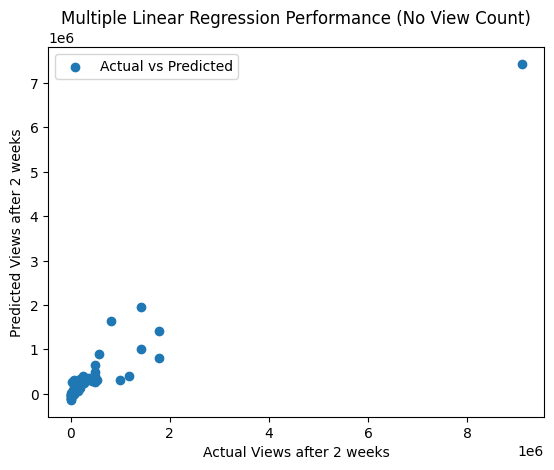

In [18]:
# Select all numeric columns except the target variable
drop_columns = ['Post 2 Weeks View Count', 'View Count']  # Target variable
X = data.select_dtypes(include=[np.number]).drop(columns=drop_columns)
y = data[['Post 2 Weeks View Count']]

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Model evaluation
coefficients = model.coef_
intercept = model.intercept_
r_squared_train = model.score(X_train, y_train)
r_squared_test = model.score(X_test, y_test)
y_pred = model.predict(X_test)

print(f"Coefficients: {coefficients}")
print(f"Intercept: {intercept}")
print(f"R^2 (Train): {r_squared_train}, R^2 (Test): {r_squared_test}")

# OLS Regression Analysis
X_with_const = sm.add_constant(X)  # Adding a constant term for statsmodels regression
ols_model = sm.OLS(y, X_with_const).fit()
like_count_p_value = ols_model.pvalues.get('View Count', None)
print(like_count_p_value)
print(ols_model.summary())

# Plot results
plt.scatter(y_test, y_pred, label="Actual vs Predicted")
plt.xlabel('Actual Views after 2 weeks')
plt.ylabel('Predicted Views after 2 weeks')
plt.title('Multiple Linear Regression Performance (No View Count)')
plt.legend()
plt.show()
